# DineIQ Analytics — Menu Item Profitability & Multi-Dimensional Margin Analysis

**Objective:** Analyze Quantity, Revenue, Cost, Contribution Margin, Profit %, Ratings, Repeat purchase, Wastage, Promotion dependency, and identify tricky edge cases.  
**Related SRS Requirement:** Step 9: Menu Profitability Analysis & SRS 11 Difficult Cases  
**Dataset / Source Used:** parquet_data/features/menu_features.parquet & processed_data/cleaned/  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
PARQUET_FEAT_DIR = os.path.join(PROJECT_ROOT, "parquet_data", "features")
menu_df = pd.read_parquet(os.path.join(PARQUET_FEAT_DIR, "menu_features.parquet"))

## 2. Multi-Dimensional Profitability Distribution

In [2]:
summary_cols = ["item_popularity", "item_revenue", "cost", "contribution_margin", "profit_percentage", "average_rating", "wastage_percentage"]
display(menu_df[summary_cols].describe().round(2))

,item_popularity,item_revenue,cost,contribution_margin,profit_percentage,average_rating
count,150.00,150.00,150.00,150.00,150.00,150.00
mean,8739.39,139881.33,61557.81,78323.51,59.67,3.62
std,4603.97,71675.52,51109.63,39366.24,17.92,0.08
min,667.00,17784.00,3705.00,-39007.50,-30.43,3.32
25%,5525.75,88693.50,28037.85,53851.05,53.11,3.57
50%,8344.50,129497.25,46471.25,74667.38,60.98,3.61
75%,11314.25,176508.25,77608.40,93849.90,71.03,3.66
max,21480.00,417790.69,257723.50,177031.00,89.41,3.82


## 3. Detecting the 4 SRS Tricky / Difficult Cases

In [3]:
# Case 1: High sales volume but low / negative profit percentage
median_vol = menu_df["item_popularity"].median()
median_profit_pct = menu_df["profit_percentage"].median()

case1 = menu_df[(menu_df["item_popularity"] > median_vol) & (menu_df["profit_percentage"] < 35.0)]
print(f"Case 1: High Sales Volume but Weak Margin ({len(case1)} items):")
display(case1[["item_id", "item_name", "item_popularity", "profit_percentage", "contribution_margin"]].head(3))

# Case 2: High Margin % but Low Sales Volume
case2 = menu_df[(menu_df["item_popularity"] < median_vol) & (menu_df["profit_percentage"] > 60.0)]
print(f"\nCase 2: High Margin % but Low Volume - Hidden Gems ({len(case2)} items):")
display(case2[["item_id", "item_name", "item_popularity", "profit_percentage", "contribution_margin"]].head(3))

# Case 3: Popular but High Wastage
median_waste = menu_df["wastage_percentage"].median()
case3 = menu_df[(menu_df["item_popularity"] > median_vol) & (menu_df["wastage_percentage"] > 12.0)]
print(f"\nCase 3: High Popularity but High Wastage ({len(case3)} items):")
display(case3[["item_id", "item_name", "item_popularity", "wastage_percentage", "contribution_margin"]].head(3))

# Case 4: High Rating but Weak Profitability
case4 = menu_df[(menu_df["average_rating"] >= 4.2) & (menu_df["contribution_margin"] < menu_df["contribution_margin"].median())]
print(f"\nCase 4: High Customer Rating but Weak Profit Contribution ({len(case4)} items):")
display(case4[["item_id", "item_name", "average_rating", "contribution_margin", "item_revenue"]].head(3))

Case 1: High Sales Volume but Weak Margin (16 items):


,item_id,item_name,item_popularity,profit_percentage,contribution_margin
2,ITEM-032,Double Pepperoni Hot Honey Pizza,18644,25.41,87626.80
4,ITEM-068,Classic Fish & Chips Tartar,15137,27.46,83102.13
5,ITEM-031,Margherita Sourdough Pizza,18735,24.95,74752.65



Case 2: High Margin % but Low Volume - Hidden Gems (33 items):


,item_id,item_name,item_popularity,profit_percentage,contribution_margin
17,ITEM-135,Red Sangria Pitcher (House Wine),7727,78.62,176175.6
37,ITEM-092,Truffle Wild Mushroom Risotto,7698,68.70,121628.4
55,ITEM-101,Thai Coconut Green Curry Tofu,8270,69.44,103375.0



Case 3: High Popularity but High Wastage (3 items):


,item_id,item_name,item_popularity,wastage_percentage,contribution_margin
35,ITEM-086,Sesame Ahi Tuna Poke Bowl,9338,47.25,86843.4
68,ITEM-098,Avocado Supergreen Toast Sourdough,9887,45.81,66242.9
127,ITEM-144,Fresh Squeezed Orange Juice,11974,42.08,34724.6



Case 4: High Customer Rating but Weak Profit Contribution (0 items):


,item_id,item_name,average_rating,contribution_margin,item_revenue


## 4. Profitability Matrix Scatter Plot

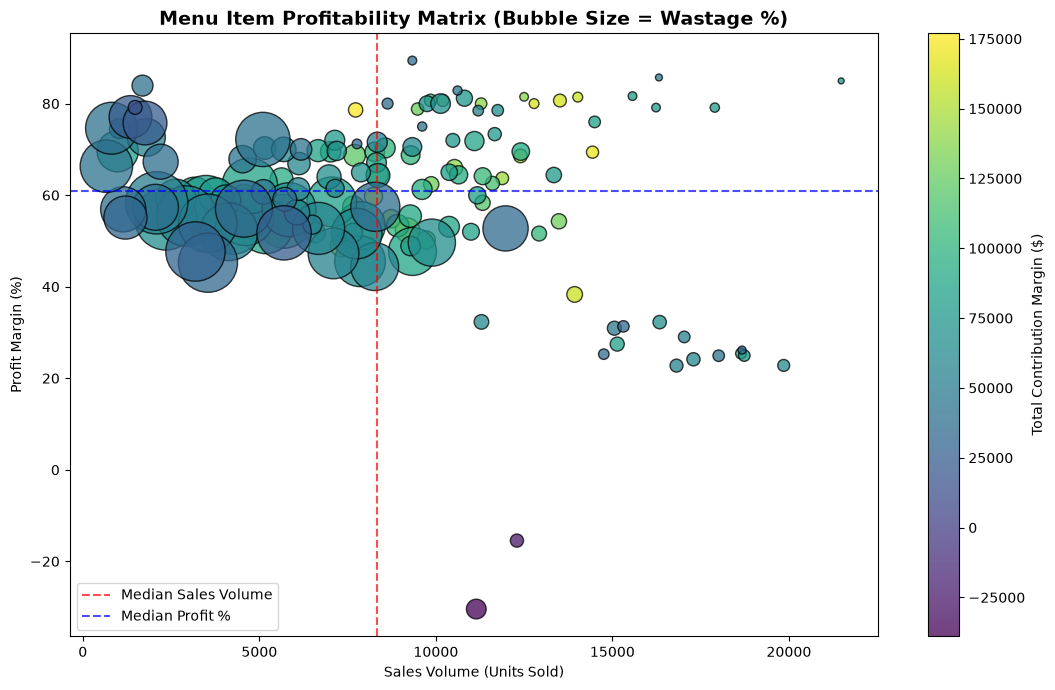

In [4]:
plt.figure(figsize=(11, 7))
waste_s = pd.to_numeric(menu_df["wastage_percentage"], errors="coerce").fillna(0.0).values * 25 + 10
scatter = plt.scatter(
    pd.to_numeric(menu_df["item_popularity"], errors="coerce").values,
    pd.to_numeric(menu_df["profit_percentage"], errors="coerce").values,
    c=pd.to_numeric(menu_df["contribution_margin"], errors="coerce").values,
    cmap="viridis",
    s=waste_s,
    alpha=0.75,
    edgecolors="black"
)
plt.colorbar(scatter, label="Total Contribution Margin ($)")
plt.axvline(median_vol, color="red", linestyle="--", alpha=0.7, label="Median Sales Volume")
plt.axhline(median_profit_pct, color="blue", linestyle="--", alpha=0.7, label="Median Profit %")
plt.title("Menu Item Profitability Matrix (Bubble Size = Wastage %)", fontsize=14, fontweight="bold")
plt.xlabel("Sales Volume (Units Sold)")
plt.ylabel("Profit Margin (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Interpretation & Conclusion
- **Hidden Gems:** Case 2 items with >60% margin but low sales require promotional visibility to scale profitability.
- **Margin Bleeders:** Case 1 items with high sales but weak margin dilute restaurant profits and need price renegotiation.
- **Conclusion:** Multi-attribute profitability analysis separates true profit drivers from misleading volume leaders.